In [1]:
!pip install drain3

  Using cached drain3-0.9.11.tar.gz (27 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached jsonpickle-1.5.1-py2.py3-none-any.whl.metadata (6.6 kB)
  Using cached cachetools-4.2.1-py3-none-any.whl.metadata (4.6 kB)
Using cached cachetools-4.2.1-py3-none-any.whl (12 kB)
Using cached jsonpickle-1.5.1-py2.py3-none-any.whl (37 kB)
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=24162 sha256=b74fede6b65887cd2e059c710cd28b8cf8316a2a50bde67a7ff14597b6aa0d72
  Stored in directory: c:\users\ktpl4_wjzjfy6\appdata\local\pip\cache\wheels\82\5a\0b\8da60e57018f6b933535590bedba43ca0fd5cf41a0e68f8e11
Successfully built drain3

   -------------------------- ------------- 2/3 [drain3]
  

In [2]:
# ============================================================
# PHẦN 1: Load log file
# ============================================================
import os

LOG_FILE = r"D:\Xbrain\Phase 2 AIops\Log Mining + Parsing + Anomaly từ Log\HDFS_2k.log"   # đổi path nếu cần

with open(LOG_FILE, "r") as f:
    lines = f.readlines()

# Bỏ dòng trống
lines = [l.strip() for l in lines if l.strip()]

print(f"Tổng số dòng log: {len(lines)}")
print(f"\nVí dụ 3 dòng đầu:")
for l in lines[:3]:
    print(" ", l)

Tổng số dòng log: 2000

Ví dụ 3 dòng đầu:
  081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
  081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
  081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864


In [13]:

# ============================================================
# PHẦN 2: Parse với Drain3
# ============================================================
# pip install drain3

from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
import re

def preprocess(line):
    # Bỏ: "081109 203615 148 " ở đầu → chỉ giữ từ INFO/WARN trở đi
    tokens = line.split()
    if len(tokens) > 3 and tokens[0].isdigit():
        return " ".join(tokens[3:])  # bỏ date, time, pid
    return line

# Dùng khi parse:
for line in lines:
    result = miner.add_log_message(preprocess(line))
def build_miner(sim_th=0.5):
    config = TemplateMinerConfig()
    config.drain_sim_th = sim_th
    config.drain_depth = 4
    return TemplateMiner(config=config)

miner = build_miner(sim_th=0.3)

parsed = []   # list of (line, cluster_id, template)

for line in lines:
    result = miner.add_log_message(line)
    parsed.append({
        "line":        line,
        "cluster_id":  result["cluster_id"],
        "template":    result["template_mined"],
    })

print(f"Parse xong. Tổng templates tìm được: {len(miner.drain.clusters)}")


Parse xong. Tổng templates tìm được: 17


In [14]:
# ============================================================
# PHẦN 3: Liệt kê templates
# ============================================================
import pandas as pd
from collections import Counter

# Đếm
counts = Counter(p["cluster_id"] for p in parsed)

template_rows = []
for cluster in miner.drain.clusters:
    template_rows.append({
        "template_id": cluster.cluster_id,
        "template":    cluster.get_template(),
        "count":       cluster.size,
    })

df_templates = pd.DataFrame(template_rows).sort_values("count", ascending=False).reset_index(drop=True)

print(df_templates.to_string(index=False))

 template_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [20]:
# ============================================================
# PHẦN 4: Export top-10 templates
# ============================================================
os.makedirs("results", exist_ok=True)

top10 = df_templates.head(10)[["template_id", "template", "count"]]
top10.to_csv("results/top_templates.csv", index=False)

print("Đã export top-10:")
print(top10.to_string(index=False))

Đã export top-10:
 template_id                                                                                                            template  count
           2 <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>    314
           1                        <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating    311
           3                              <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>    292
           4                                   <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>    292
           7                                                         <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>    263
          10                      <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>    224
           5                  

In [17]:
# ============================================================
# PHẦN 5: Tune drain_sim_th
# ============================================================

results_tune = []

for sim_th in [0.3, 0.5, 0.7]:
    m = build_miner(sim_th=sim_th)
    for line in lines:
        m.add_log_message(line)
    n_templates = len(m.drain.clusters)
    results_tune.append({"sim_th": sim_th, "n_templates": n_templates})
    print(f"sim_th={sim_th}  →  {n_templates} templates")

# Chọn giá trị tốt nhất
# Gợi ý: sim_th=0.5 (balance) trừ khi log quá diverse hoặc quá uniform
df_tune = pd.DataFrame(results_tune)
print("\nBảng tổng hợp:")
print(df_tune.to_string(index=False))

# Nhận xét tự động
best = df_tune[df_tune["n_templates"] > 3].iloc[0]  # tránh quá ít template
print(f"\nChọn: sim_th={best['sim_th']} ({best['n_templates']} templates)")

sim_th=0.3  →  17 templates
sim_th=0.5  →  21 templates
sim_th=0.7  →  820 templates

Bảng tổng hợp:
 sim_th  n_templates
    0.3           17
    0.5           21
    0.7          820

Chọn: sim_th=0.3 (17.0 templates)


##PHASE 2##

In [18]:
# ============================================================
# PHASE 2 - PHẦN 1: Template Count Time Series
# ============================================================
import pandas as pd
from datetime import datetime

def parse_timestamp(line):
    """Lấy timestamp từ dòng log: 081109 203615 → datetime"""
    tokens = line.split()
    if len(tokens) < 2:
        return None
    try:
        date_str = tokens[0]  # 081109 = tháng 08, ngày 11, năm 09
        time_str = tokens[1]  # 203615 = 20:36:15
        dt = datetime.strptime(f"20{date_str} {time_str}", "%Y%m%d %H%M%S")
        return dt
    except:
        return None

# Build dataframe: timestamp + template_id mỗi dòng
log_entries = []
for p in parsed:
    ts = parse_timestamp(p["line"])
    if ts:
        log_entries.append({
            "timestamp":   ts,
            "template_id": p["cluster_id"],
        })

df_log = pd.DataFrame(log_entries)
df_log["timestamp"] = pd.to_datetime(df_log["timestamp"])
df_log = df_log.sort_values("timestamp").reset_index(drop=True)

print(f"Time range: {df_log['timestamp'].min()} → {df_log['timestamp'].max()}")
print(f"Tổng entries: {len(df_log)}")

# Window 5 phút → đếm số lần mỗi template xuất hiện
ts = df_log.groupby([
    pd.Grouper(key="timestamp", freq="5min"),
    "template_id"
]).size().unstack(fill_value=0)

print("Template count time series (5 phút):")
print(ts.head(10))

Time range: 2008-11-09 20:36:15 → 2008-11-11 10:20:17
Tổng entries: 2000
Template count time series (5 phút):
template_id          1   2   3   4   5   6   7   8   9   10  11  12  13  14  \
timestamp                                                                     
2008-11-09 20:35:00   2   0   0   0   0   0   0   0   0   0   0   0   0   0   
2008-11-09 20:40:00   2   4   0   0   0   0   0   0   0   0   0   0   0   0   
2008-11-09 20:45:00   1   1   2   3   0   0   0   0   0   0   0   0   0   0   
2008-11-09 20:50:00   1   1   2   0   2   0   0   0   0   0   0   0   0   0   
2008-11-09 20:55:00   0   3   2   1   1   1   0   0   0   0   0   0   0   0   
2008-11-09 21:00:00   0   1   2   2   0   0   0   0   0   0   0   0   0   0   
2008-11-09 21:05:00   0   2   6   2   0   0   0   0   0   0   0   0   0   0   
2008-11-09 21:10:00   2   3   2   0   0   0   0   0   0   0   0   0   0   0   
2008-11-09 21:15:00   2   1   0   0   0   0   0   0   0   0   0   0   0   0   
2008-11-09 21:20:00  

In [19]:
# ============================================================
# PHASE 2 - PHẦN 3: 3σ Anomaly Detection
# ============================================================
import numpy as np

def detect_anomaly_3sigma(series):
    """Trả về boolean mask: True = anomaly"""
    mean = series.mean()
    std  = series.std()
    if std == 0:
        return pd.Series(False, index=series.index)
    return (series - mean).abs() > 3 * std

anomalies = {}
for template_id in ts.columns:
    mask = detect_anomaly_3sigma(ts[template_id])
    if mask.any():
        anomalies[template_id] = ts[template_id][mask]

print(f"\nTemplates có anomaly: {list(anomalies.keys())}")
for tid, windows in anomalies.items():
    print(f"\nTemplate {tid}:")
    for t, count in windows.items():
        print(f"  {t}  count={count}")


Templates có anomaly: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Template 1:
  2008-11-10 01:40:00  count=5
  2008-11-10 23:05:00  count=5
  2008-11-11 02:55:00  count=5
  2008-11-11 07:20:00  count=5
  2008-11-11 07:30:00  count=5
  2008-11-11 08:40:00  count=6
  2008-11-11 10:10:00  count=6

Template 2:
  2008-11-10 12:30:00  count=5
  2008-11-10 15:05:00  count=5
  2008-11-11 03:00:00  count=5
  2008-11-11 09:55:00  count=8

Template 3:
  2008-11-09 21:05:00  count=6
  2008-11-10 01:35:00  count=5
  2008-11-10 11:00:00  count=5
  2008-11-11 07:35:00  count=6

Template 4:
  2008-11-10 11:40:00  count=5
  2008-11-10 14:35:00  count=5
  2008-11-11 03:00:00  count=5

Template 5:
  2008-11-10 01:45:00  count=4
  2008-11-10 01:55:00  count=3
  2008-11-11 06:30:00  count=3
  2008-11-11 07:45:00  count=3
  2008-11-11 08:45:00  count=3

Template 6:
  2008-11-09 20:55:00  count=1
  2008-11-09 21:30:00  count=1
  2008-11-10 00:20:00  count=1
  2008-11-10 01:10:00  count=1
  

In [21]:
# ============================================================
# PHASE 2 - PHẦN 3: Isolation Forest Anomaly Detection
# ============================================================

from sklearn.ensemble import IsolationForest

def detect_anomaly_if(series,
                      contamination=0.01,
                      random_state=42):
    """
    Trả về boolean mask:
    True = anomaly
    """

    X = series.values.reshape(-1, 1)

    clf = IsolationForest(
        contamination=contamination,
        random_state=random_state
    )

    preds = clf.fit_predict(X)

    return pd.Series(
        preds == -1,
        index=series.index
    )

anomalies = {}

for template_id in ts.columns:

    series = ts[template_id]

    # bỏ qua template quá ít dữ liệu
    if series.sum() == 0:
        continue

    mask = detect_anomaly_if(
        series,
        contamination=0.01
    )

    if mask.any():
        anomalies[template_id] = series[mask]

print("\nTemplates có anomaly:")
print(list(anomalies.keys()))

for tid, windows in anomalies.items():

    print(f"\nTemplate {tid}:")

    for t, count in windows.items():

        print(
            f"  {t}  count={count}"
        )


Templates có anomaly:
[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Template 1:
  2008-11-11 08:40:00  count=6
  2008-11-11 10:10:00  count=6

Template 2:
  2008-11-10 12:30:00  count=5
  2008-11-10 15:05:00  count=5
  2008-11-11 03:00:00  count=5
  2008-11-11 09:55:00  count=8

Template 3:
  2008-11-09 21:05:00  count=6
  2008-11-10 01:35:00  count=5
  2008-11-10 11:00:00  count=5
  2008-11-11 07:35:00  count=6

Template 4:
  2008-11-10 11:40:00  count=5
  2008-11-10 14:35:00  count=5
  2008-11-11 03:00:00  count=5

Template 5:
  2008-11-10 01:45:00  count=4

Template 7:
  2008-11-10 10:35:00  count=45
  2008-11-10 21:05:00  count=31
  2008-11-11 04:45:00  count=32
  2008-11-11 06:55:00  count=8

Template 8:
  2008-11-10 08:05:00  count=6

Template 9:
  2008-11-10 08:25:00  count=4

Template 10:
  2008-11-10 10:30:00  count=64
  2008-11-10 21:00:00  count=36
  2008-11-11 04:40:00  count=25
  2008-11-11 07:55:00  count=13

Template 11:
  2008-11-10 21:15:00  count=1

Templ

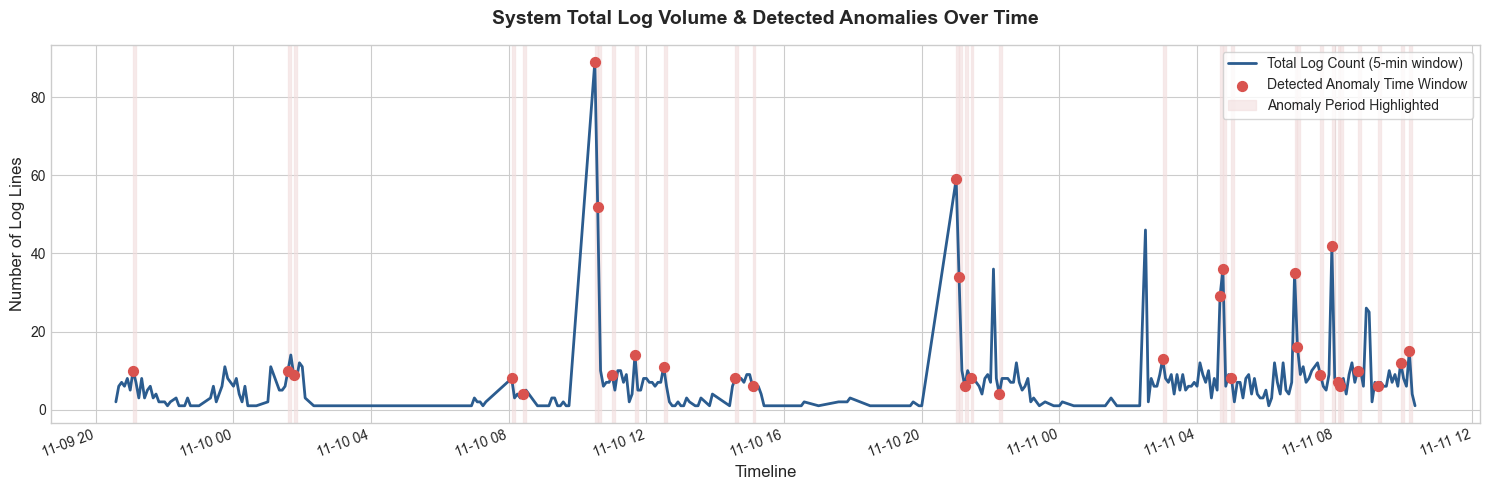

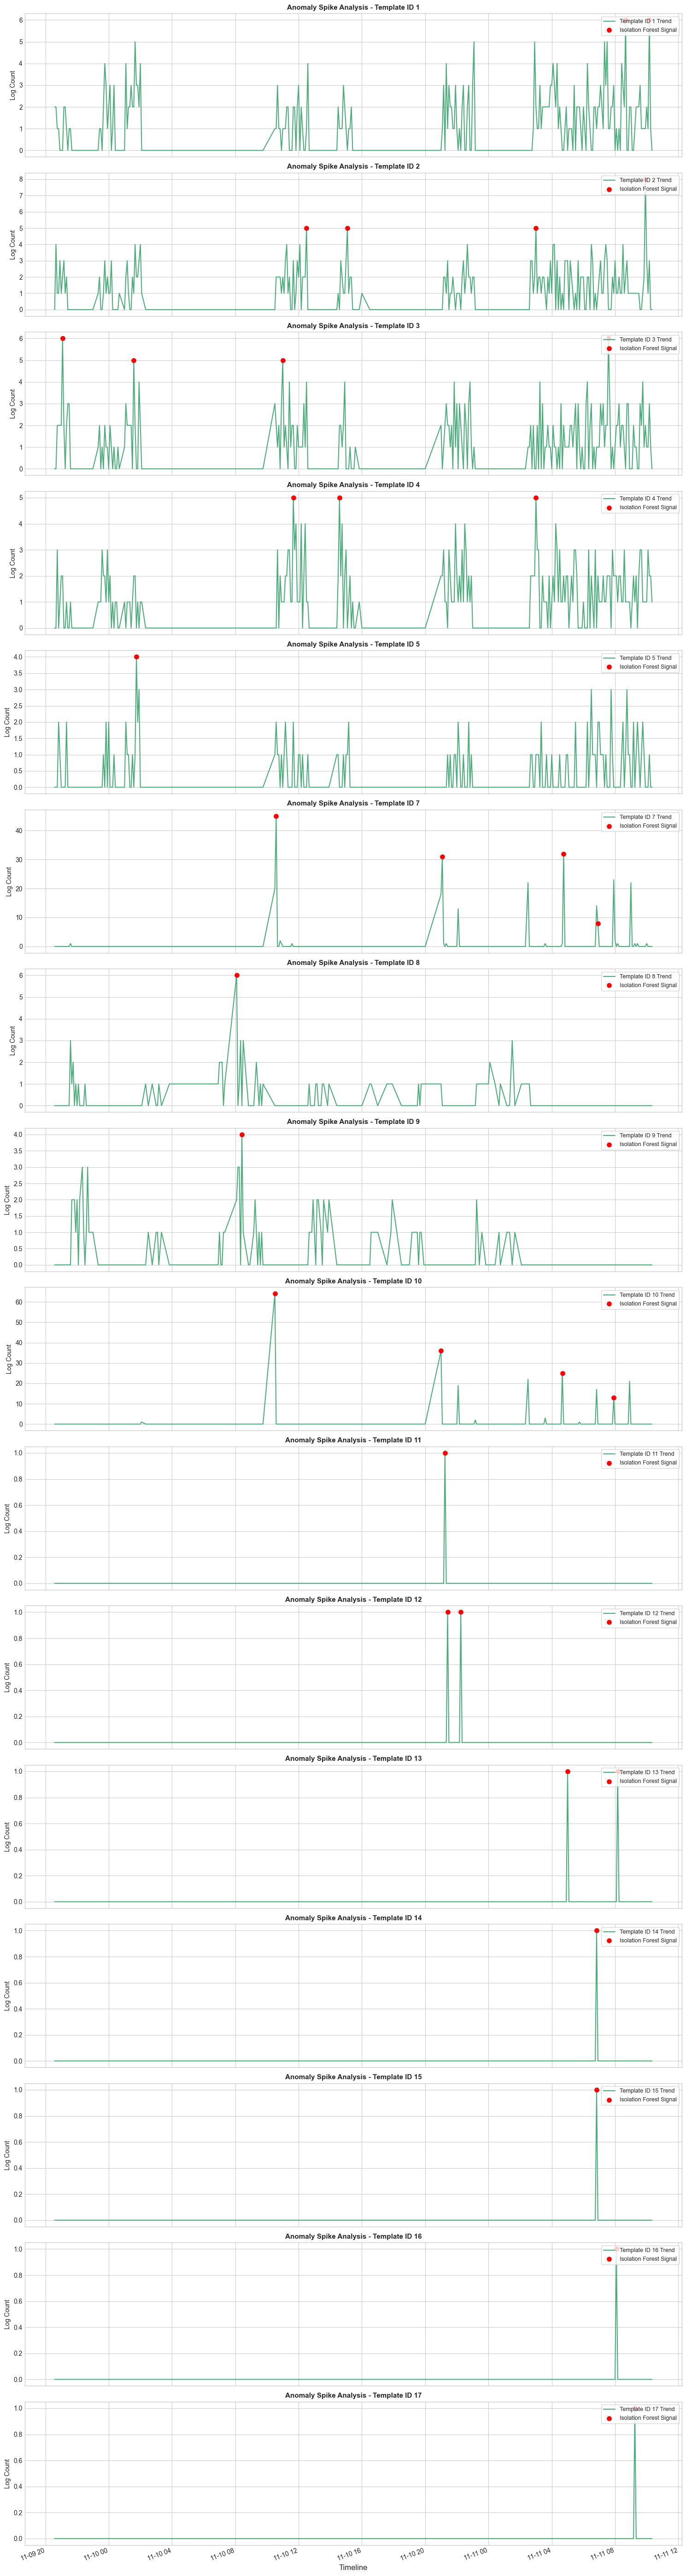

In [29]:
# ============================================================
# PHASE 2 - PHẦN 4: Trực quan hóa Time Series & Highlight Anomaly
# ============================================================
import matplotlib.pyplot as plt

# Sử dụng style sạch sẽ, trực quan
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('ggplot')

# ------------------------------------------------------------
# 1. Vẽ Biểu Đồ Tổng Lưu Lượng Log (Total Log Volume Time Series)
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(15, 5))

# Tính tổng số log của tất cả các template gộp lại trong mỗi 5 phút
total_log_ts = ts.sum(axis=1)
ax1.plot(total_log_ts.index, total_log_ts.values, label="Total Log Count (5-min window)", color="#2b5c8f", linewidth=2)

# Tập hợp toàn bộ các mốc timestamp bị coi là Anomaly bởi bất kỳ template nào
all_anomaly_timestamps = set()
for template_id in ts.columns:
    series = ts[template_id]
    if series.sum() == 0:
        continue
    mask = detect_anomaly_if(series, contamination=0.01)
    # Thêm các mốc thời gian thỏa mãn mask == True
    all_anomaly_timestamps.update(series[mask].index)

# Highlight các điểm bất thường trên đồ thị tổng thể
if all_anomaly_timestamps:
    anomaly_list = sorted(list(all_anomaly_timestamps))
    total_log_anomalies = total_log_ts.loc[anomaly_list]
    
    # Chấm đỏ tại đỉnh điểm xảy ra sự cố
    ax1.scatter(anomaly_list, total_log_anomalies, color="#d9534f", s=50, zorder=5, label="Detected Anomaly Time Window")
    
    # Vẽ các dải màu đỏ mờ (Vertical Span) bao bọc cửa sổ thời gian đó để highlight
    for idx, anomaly_time in enumerate(anomaly_list):
        # Chỉ gán label cho thanh đầu tiên để tránh trùng lặp trong Chú thích (Legend)
        lbl = "Anomaly Period Highlighted" if idx == 0 else ""
        ax1.axvspan(anomaly_time, anomaly_time + pd.Timedelta(minutes=5), color="#f2dede", alpha=0.6, label=lbl, zorder=1)

ax1.set_title("System Total Log Volume & Detected Anomalies Over Time", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Timeline", fontsize=12)
ax1.set_ylabel("Number of Log Lines", fontsize=12)
ax1.legend(loc="upper right", frameon=True, facecolor="white")
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
fig1.savefig("template_time_series.png", dpi=300) # Xuất ảnh ra đúng tên khai báo trong SUBMIT.md
plt.show()


# ------------------------------------------------------------
# 2. Vẽ Biểu Đồ Chi Tiết Từng Template Có Anomaly
# ------------------------------------------------------------
# Tìm danh sách các template thực sự chứa điểm bất thường
active_anomaly_tids = []
for template_id in ts.columns:
    series = ts[template_id]
    if series.sum() > 0:
        mask = detect_anomaly_if(series, contamination=0.01)
        if mask.any():
            active_anomaly_tids.append(template_id)

if active_anomaly_tids:
    # Khởi tạo subplots động dựa trên số lượng template lỗi phát hiện được
    num_plots = len(active_anomaly_tids)
    fig2, axs = plt.subplots(num_plots, 1, figsize=(15, 3.5 * num_plots), sharex=True)
    
    # Đảm bảo axs luôn ở dạng list tuần tự kể cả khi chỉ có 1 subplot lỗi
    if num_plots == 1:
        axs = [axs]
        
    for i, tid in enumerate(active_anomaly_tids):
        series = ts[tid]
        mask = detect_anomaly_if(series, contamination=0.01)
        
        # Vẽ đường chuỗi thời gian của riêng template đó
        axs[i].plot(series.index, series.values, color="#4bad7a", linewidth=1.5, label=f"Template ID {tid} Trend")
        
        # Điểm chấm đỏ nổi bật (Spike Highlight)
        anomaly_points = series[mask]
        axs[i].scatter(anomaly_points.index, anomaly_points.values, color="red", s=45, zorder=5, label="Isolation Forest Signal")
        
        axs[i].set_title(f"Anomaly Spike Analysis - Template ID {tid}", fontsize=11, fontweight='semibold')
        axs[i].set_ylabel("Log Count", fontsize=10)
        axs[i].legend(loc="upper right", frameon=True, fontsize=9)
        
    axs[-1].set_xlabel("Timeline", fontsize=12)
    plt.setp(axs[-1].get_xticklabels(), rotation=20, ha="right")
    
    plt.tight_layout()
    fig2.savefig("anomaly_highlight.png", dpi=300) # Xuất ảnh ra đúng tên khai báo trong SUBMIT.md
    plt.show()
else:
    print("Không tìm thấy Template ID nào có điểm đột biến bất thường vượt ngưỡng Isolation Forest.")

In [22]:
anomaly_rows = []

for template_id in ts.columns:

    series = ts[template_id]

    if series.sum() == 0:
        continue

    mask = detect_anomaly_if(
        series,
        contamination=0.01
    )

    anomaly_points = series[mask]

    for timestamp, count in anomaly_points.items():

        anomaly_rows.append({
            "template_id": template_id,
            "timestamp": timestamp,
            "count": count
        })

df_anomaly = pd.DataFrame(anomaly_rows)

df_anomaly.sort_values(
    "timestamp"
)

,template_id,timestamp,count
6,3,2008-11-09 21:05:00,6
7,3,2008-11-10 01:35:00,5
13,5,2008-11-10 01:45:00,4
18,8,2008-11-10 08:05:00,6
19,9,2008-11-10 08:25:00,4
20,10,2008-11-10 10:30:00,64
14,7,2008-11-10 10:35:00,45
8,3,2008-11-10 11:00:00,5
10,4,2008-11-10 11:40:00,5
2,2,2008-11-10 12:30:00,5


In [23]:
print("\n===== Isolation Forest Anomalies =====")
print(df_anomaly.to_string(index=False))



===== Isolation Forest Anomalies =====
 template_id           timestamp  count
           1 2008-11-11 08:40:00      6
           1 2008-11-11 10:10:00      6
           2 2008-11-10 12:30:00      5
           2 2008-11-10 15:05:00      5
           2 2008-11-11 03:00:00      5
           2 2008-11-11 09:55:00      8
           3 2008-11-09 21:05:00      6
           3 2008-11-10 01:35:00      5
           3 2008-11-10 11:00:00      5
           3 2008-11-11 07:35:00      6
           4 2008-11-10 11:40:00      5
           4 2008-11-10 14:35:00      5
           4 2008-11-11 03:00:00      5
           5 2008-11-10 01:45:00      4
           7 2008-11-10 10:35:00     45
           7 2008-11-10 21:05:00     31
           7 2008-11-11 04:45:00     32
           7 2008-11-11 06:55:00      8
           8 2008-11-10 08:05:00      6
           9 2008-11-10 08:25:00      4
          10 2008-11-10 10:30:00     64
          10 2008-11-10 21:00:00     36
          10 2008-11-11 04:40:00     25


In [24]:
print("\n===== First Appearance of Templates =====")

first_seen = (
    df_log.groupby("template_id")["timestamp"]
    .min()
    .reset_index()
    .sort_values("timestamp")
)

print(first_seen.to_string(index=False))


===== First Appearance of Templates =====
 template_id           timestamp
           1 2008-11-09 20:36:15
           2 2008-11-09 20:40:05
           3 2008-11-09 20:46:55
           4 2008-11-09 20:48:15
           5 2008-11-09 20:50:35
           6 2008-11-09 20:59:31
           7 2008-11-09 21:38:37
           8 2008-11-09 21:38:47
           9 2008-11-09 21:40:43
          10 2008-11-10 02:07:24
          11 2008-11-10 21:15:41
          12 2008-11-10 21:25:10
          13 2008-11-11 05:03:34
          14 2008-11-11 06:52:54
          15 2008-11-11 06:53:03
          16 2008-11-11 08:09:34
          17 2008-11-11 09:17:33


In [27]:
# ============================================================
# PHASE 3 - PHẦN 1: TF-IDF + Cosine Similarity Matrix + Gom cụm Template
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import numpy as np

print("===== Phase 3: Embedding & Clustering Templates =====")

# 1. Chuẩn bị danh sách text của các template từ miner (loại bỏ ký tự đặc biệt <*> hoặc *)
raw_templates = []
template_ids = []

for cluster in miner.drain.clusters:
    template_ids.append(cluster.cluster_id)
    # Làm sạch chuỗi template: thay <*> hoặc * bằng khoảng trắng để vectorizer chỉ lấy từ ngữ nghĩa
    cleaned_tmpl = cluster.get_template().replace("<*>", "").replace("*", "")
    raw_templates.append(cleaned_tmpl)

print(f"Số lượng template đưa vào gom cụm: {len(raw_templates)}")

# 2. Trích xuất đặc trưng TF-IDF từ văn bản template
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(raw_templates)

# 3. Tính toán Ma trận tương đồng Cosine (Cosine Similarity Matrix)
sim_matrix = cosine_similarity(tfidf_matrix)
print("\nKích thước Ma trận Tương đồng (Similarity Matrix):", sim_matrix.shape)

# 4. Gom cụm các template bằng AgglomerativeClustering dựa trên ma trận khoảng cách (1 - similarity)
# Chúng ta đặt threshold tương đồng tối thiểu để vào cùng 1 cụm là 0.5 (khoảng cách tối đa 1 - 0.5 = 0.5)
distance_threshold = 0.5 
clustering = AgglomerativeClustering(
    n_clusters=None, 
    metric='precomputed', 
    linkage='average', 
    distance_threshold=distance_threshold
)

# Chuyển đổi ma trận tương đồng sang ma trận khoảng cách (Distance Matrix)
# Đảm bảo các giá trị không âm và đặt các giá trị chéo về chính xác 0
dist_matrix = 1 - sim_matrix
dist_matrix = np.clip(dist_matrix, 0, 1)
np.fill_diagonal(dist_matrix, 0)

cluster_labels = clustering.fit_predict(dist_matrix)

# 5. Tạo DataFrame để quan sát kết quả các Cụm Template
df_clusters = pd.DataFrame({
    "template_id": template_ids,
    "cleaned_template": raw_templates,
    "cluster_group": cluster_labels
})

print("\nKết quả phân cụm các Template dựa trên ngữ nghĩa TF-IDF:")
for group in sorted(df_clusters["cluster_group"].unique()):
    print(f"\n--- [Cụm Template Nhóm {group}] ---")
    sub_df = df_clusters[df_clusters["cluster_group"] == group]
    for idx, row in sub_df.iterrows():
        print(f"  > ID {row['template_id']}: {row['cleaned_template'].strip()}")

===== Phase 3: Embedding & Clustering Templates =====
Số lượng template đưa vào gom cụm: 17

Kích thước Ma trận Tương đồng (Similarity Matrix): (17, 17)

Kết quả phân cụm các Template dựa trên ngữ nghĩa TF-IDF:

--- [Cụm Template Nhóm 0] ---
  > ID 4: INFO dfs.DataNode$DataXceiver: Receiving block  src:  dest:
  > ID 13: 081111   INFO dfs.DataNode$DataXceiver: Received block  src:  dest:  of size 67108864

--- [Cụm Template Nhóm 1] ---
  > ID 16: 081111 080934 19 INFO dfs.FSNamesystem: BLOCK ask 10.250.14.38:50010 to replicate blk_-7571492020523929240 to datanode(s) 10.251.122.38:50010

--- [Cụm Template Nhóm 2] ---
  > ID 1: INFO dfs.DataNode$PacketResponder: PacketResponder  for block  terminating
  > ID 3: INFO dfs.DataNode$PacketResponder: Received block  of size  from

--- [Cụm Template Nhóm 3] ---
  > ID 12: 081110  19 INFO dfs.FSNamesystem: BLOCK ask  to delete

--- [Cụm Template Nhóm 4] ---
  > ID 11: 081110 211541 18 INFO dfs.DataNode: 10.250.15.198:50010 Starting thread to tr

In [28]:
# ============================================================
# PHASE 3 - PHẦN 2: Inject Log lạ & Kiểm tra phát hiện của Drain3
# ============================================================

# 1. Tạo 1 dòng log "lạ" hoàn toàn khác biệt với cấu trúc HDFS thông thường
# Các log cũ chủ yếu xoay quanh: PacketResponder, BlockMap updated, Deleting block, Served block,...
injected_log = "081111 112233 999 FATAL security.auth.MaliciousAccess: ALERT* Critical security breach: Unauthorized intrusion attempt detected from attacker IP 192.168.99.99"

print("Dòng log lạ được inject vào hệ thống:")
print(f" -> '{injected_log}'\n")

# 2. Tiền xử lý dòng log theo hàm preprocess đã định nghĩa ở Phase 1
processed_injected_log = preprocess(injected_log)

# 3. Đưa dòng log lạ vào Drain3 Miner để kiểm tra việc tạo New Template
result_injected = miner.add_log_message(processed_injected_log)

print("===== KẾT QUẢ PHÂN TÍCH TỪ DRAIN3 =====")
print(f"Trạng thái xử lý log  : {result_injected['change_type']}")
print(f"Assigned Template ID  : {result_injected['cluster_id']}")
print(f"Mined Template Text   : {result_injected['template_mined']}")

# 4. Cơ chế tự động phát hiện Anomaly (Rule-based kết hợp kiến thức lịch sử)
# Nếu ID này chưa từng tồn tại trong danh sách template ban đầu (template_ids thu thập trước đó) -> Cảnh báo ngay!
if result_injected['cluster_id'] not in template_ids:
    print("\n[DETECTED ANOMALY] >>> CẢNH BÁO NGUY HIỂM! Phát hiện Log Template mới tinh xuất hiện trong hệ thống!")
    print(f" -> Loại lỗi mới: Template ID {result_injected['cluster_id']} không nằm trong Baseline Core.")
else:
    print("\n[NORMAL] Log này trùng khớp hoặc gom chung nhóm cấu trúc với một template có sẵn.")

Dòng log lạ được inject vào hệ thống:
 -> '081111 112233 999 FATAL security.auth.MaliciousAccess: ALERT* Critical security breach: Unauthorized intrusion attempt detected from attacker IP 192.168.99.99'

===== KẾT QUẢ PHÂN TÍCH TỪ DRAIN3 =====
Trạng thái xử lý log  : cluster_created
Assigned Template ID  : 18
Mined Template Text   : FATAL security.auth.MaliciousAccess: ALERT* Critical security breach: Unauthorized intrusion attempt detected from attacker IP 192.168.99.99

[DETECTED ANOMALY] >>> CẢNH BÁO NGUY HIỂM! Phát hiện Log Template mới tinh xuất hiện trong hệ thống!
 -> Loại lỗi mới: Template ID 18 không nằm trong Baseline Core.
